✓ Semua library berhasil diimport!
KONVERSI FOTO KE SKETSA BERBASIS WAVELET
Real-Time Photo to Sketch Converter

Developed by: Thia Shopy Latifah (20123076)
Universitas Teknologi Digital

📤 Silakan upload gambar...


Saving 20123076.jpg to 20123076.jpg
✓ Gambar '20123076.jpg' berhasil dimuat!
  Ukuran: (330, 255, 3)

PILIH METODE:
  1. Semua Metode (Rekomendasi)
  2. DWT Edge Detection
  3. Wavelet Entropy
  4. Mexican Hat Wavelet
  5. Gabor Wavelet
  6. Adaptive Wavelet
  7. High Frequency Enhanced

PILIH STYLE:
  1. Pencil (Soft, Natural)
  2. Ink (Sharp, High Contrast)
  3. Charcoal (Artistic)

→ Menggunakan style: PENCIL
→ Processing gambar...

→ Processing DWT Edge Detection...
→ Processing Wavelet Entropy Edge Detection...
→ Processing Mexican Hat Wavelet...
→ Processing Gabor Wavelet...
→ Processing Adaptive Wavelet...
→ Processing High Frequency Enhancement...

✓ Processing selesai dalam 1.02 detik

→ Menampilkan hasil...



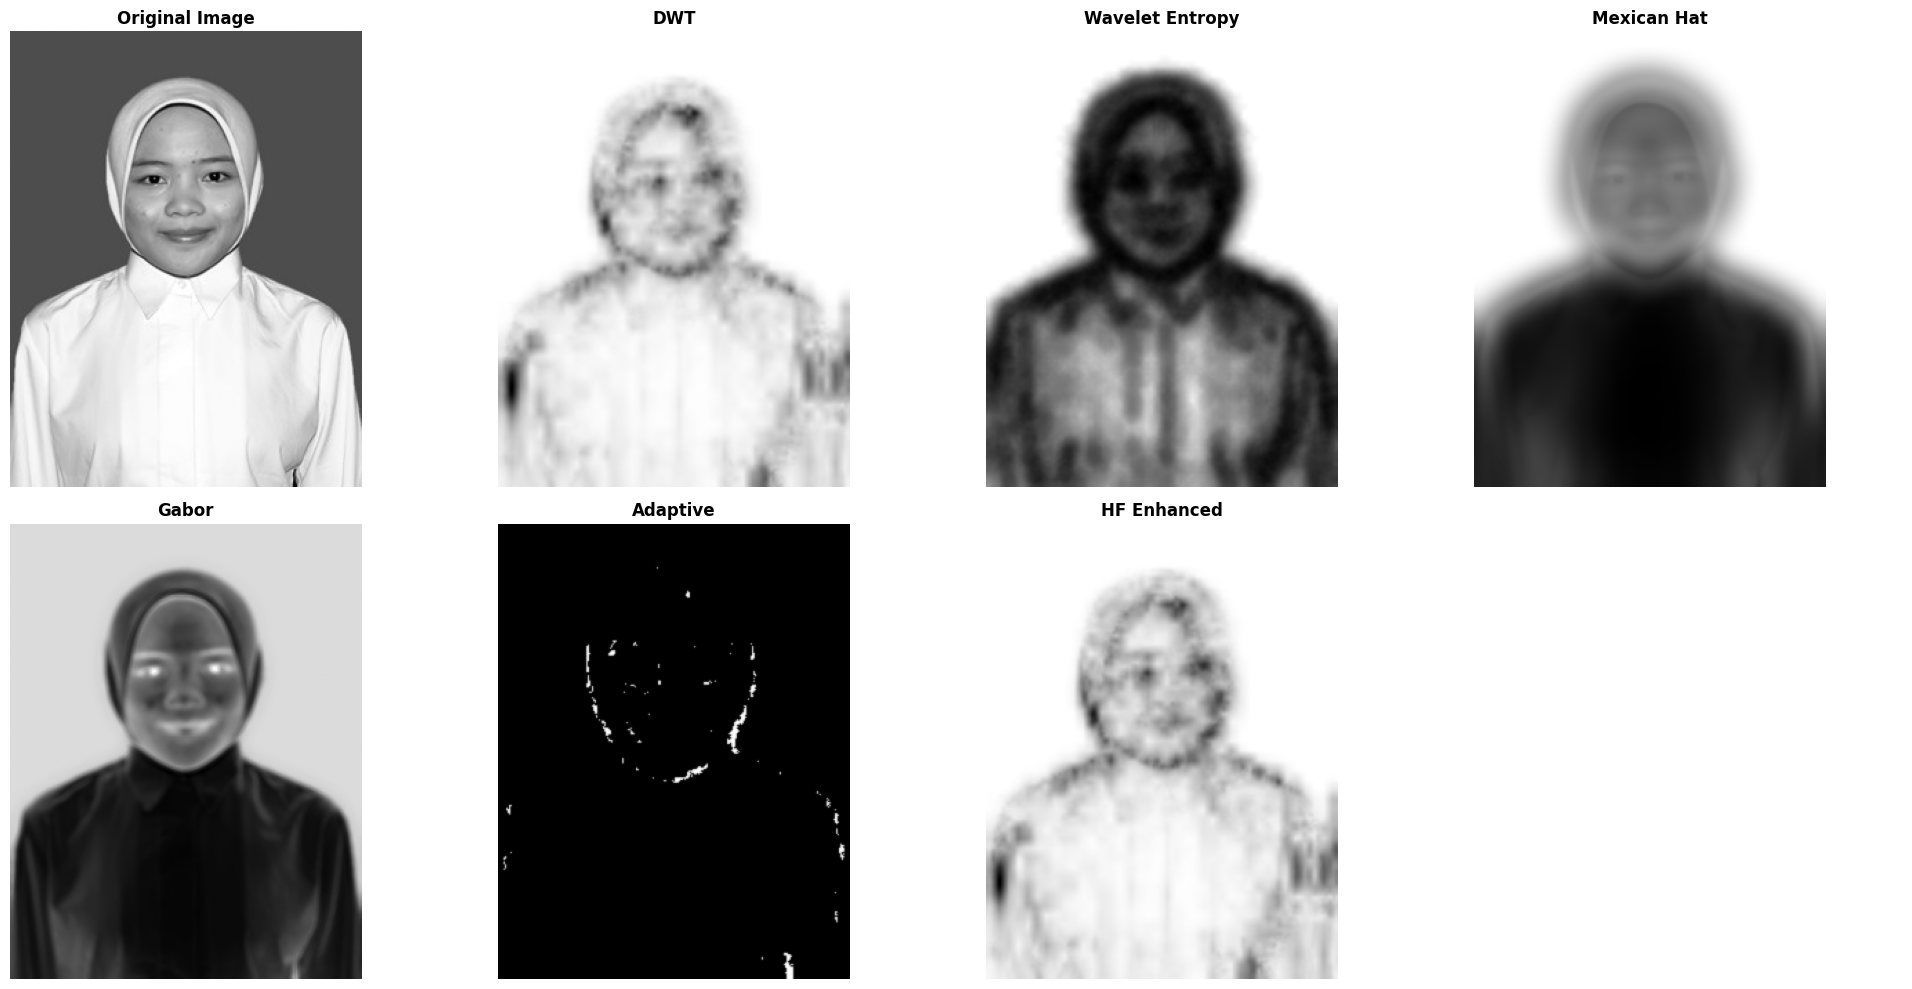


METRIK EVALUASI

DWT:
  • SSIM: 0.4772
  • PSNR: 6.93 dB
  • Edge Density: 1.83%

Wavelet Entropy:
  • SSIM: 0.3034
  • PSNR: 4.66 dB
  • Edge Density: 51.40%

Mexican Hat:
  • SSIM: 0.2597
  • PSNR: 3.43 dB
  • Edge Density: 52.69%

Gabor:
  • SSIM: 0.1738
  • PSNR: 3.81 dB
  • Edge Density: 56.35%

Adaptive:
  • SSIM: -0.0007
  • PSNR: 3.33 dB
  • Edge Density: 99.19%

HF Enhanced:
  • SSIM: 0.4650
  • PSNR: 6.95 dB
  • Edge Density: 2.22%


→ Menyimpan hasil sketsa...
  ✓ sketch_dwt.png
  ✓ sketch_wavelet_entropy.png
  ✓ sketch_mexican_hat.png
  ✓ sketch_gabor.png
  ✓ sketch_adaptive.png
  ✓ sketch_hf_enhanced.png

✓ PROSES SELESAI!


In [12]:
"""
Konversi Real-Time Foto ke Sketsa dengan Teknik Edge Enhancement Berbasis Wavelet
Implementasi untuk Google Colab
Author: Thia Shopy Latifah (20123076)
Universitas Teknologi Digital
"""

# ============================================================================
# 1. INSTALASI DAN IMPORT LIBRARIES
# ============================================================================

# Install library yang diperlukan
!pip install pywavelets opencv-python-headless matplotlib scipy scikit-image pillow numpy

import cv2
import numpy as np
import pywt
import matplotlib.pyplot as plt
from scipy import ndimage
from scipy.ndimage import gaussian_filter
from skimage import exposure, filters
from google.colab import files
from google.colab.patches import cv2_imshow
import io
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

print("✓ Semua library berhasil diimport!")

# ============================================================================
# 2. FUNGSI UTILITY
# ============================================================================

def load_image(uploaded_file):
    """Memuat gambar dari upload"""
    image = Image.open(io.BytesIO(uploaded_file))
    image = np.array(image)
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    return image

def preprocess_image(image, target_size=512):
    """Preprocessing gambar"""
    # Konversi ke grayscale jika berwarna
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # Resize untuk processing lebih cepat
    h, w = gray.shape
    if max(h, w) > target_size:
        scale = target_size / max(h, w)
        new_w, new_h = int(w * scale), int(h * scale)
        gray = cv2.resize(gray, (new_w, new_h))

    # Normalisasi
    gray = gray.astype(np.float64) / 255.0

    return gray

# ============================================================================
# 3. METODE 1: DISCRETE WAVELET TRANSFORM (DWT) EDGE DETECTION
# ============================================================================

def dwt_edge_detection(image, wavelet='db4', level=3):
    """
    Deteksi tepi menggunakan DWT

    Parameters:
    - image: input grayscale image (normalized)
    - wavelet: wavelet family (db4, sym4, coif1, dll)
    - level: decomposition level
    """
    coeffs = pywt.wavedec2(image, wavelet, level=level)

    # Ekstrak koefisien detail (high frequency)
    cA = coeffs[0]
    details = coeffs[1:]

    # Kombinasi horizontal, vertical, dan diagonal details
    edges = np.zeros_like(image)

    for detail_level in details:
        cH, cV, cD = detail_level
        # Magnitude dari detail coefficients
        magnitude = np.sqrt(cH**2 + cV**2 + cD**2)

        # Upsample ke ukuran original
        h, w = edges.shape
        magnitude_resized = cv2.resize(magnitude, (w, h))
        edges += magnitude_resized

    # Normalisasi
    edges = (edges - edges.min()) / (edges.max() - edges.min())

    return edges, coeffs

# ============================================================================
# 4. METODE 2: WAVELET ENTROPY EDGE DETECTION
# ============================================================================

def calculate_local_entropy(image, window_size=5):
    """Menghitung entropi lokal"""
    from skimage.filters.rank import entropy
    from skimage.morphology import disk

    # Konversi ke uint8
    image_uint8 = (image * 255).astype(np.uint8)

    # Hitung entropi lokal
    local_entropy = entropy(image_uint8, disk(window_size))

    return local_entropy / 255.0

def wavelet_entropy_edge_detection(image, wavelet='db4', level=2):
    """
    Deteksi tepi menggunakan Wavelet Entropy

    Berdasarkan: Dwivedi et al. (2023) - Wavelet Entropy: A New Tool for Edge Detection
    """
    # Dekomposisi wavelet
    coeffs = pywt.wavedec2(image, wavelet, level=level)

    # Hitung entropi untuk setiap sub-band
    edges_entropy = np.zeros_like(image)

    for i, detail_level in enumerate(coeffs[1:]):
        cH, cV, cD = detail_level

        # Hitung magnitude
        magnitude = np.sqrt(cH**2 + cV**2 + cD**2)

        # Hitung entropi lokal
        entropy_map = calculate_local_entropy(magnitude, window_size=3)

        # Resize ke ukuran original
        h, w = edges_entropy.shape
        entropy_resized = cv2.resize(entropy_map, (w, h))
        edges_entropy += entropy_resized

    # Normalisasi
    edges_entropy = (edges_entropy - edges_entropy.min()) / (edges_entropy.max() - edges_entropy.min())

    return edges_entropy

# ============================================================================
# 5. METODE 3: MEXICAN HAT WAVELET EDGE DETECTION
# ============================================================================

def mexican_hat_wavelet(x, y, sigma=1.0):
    """Mexican Hat (Ricker) wavelet function"""
    r_squared = x**2 + y**2
    coefficient = 2 / (np.sqrt(3 * sigma) * np.pi**0.25)
    gaussian = np.exp(-r_squared / (2 * sigma**2))
    polynomial = (1 - r_squared / sigma**2)
    return coefficient * polynomial * gaussian

def enhanced_mexican_hat_edge_detection(image, scales=[1, 2, 4, 8]):
    """
    Enhanced Mexican Hat Wavelet Transform untuk deteksi tepi

    Berdasarkan: Wang et al. (2025) - Enhanced Mexican Hat Wavelet Transform
    """
    edges = np.zeros_like(image)

    for scale in scales:
        # Buat kernel Mexican Hat
        kernel_size = int(6 * scale + 1)
        if kernel_size % 2 == 0:
            kernel_size += 1

        x = np.linspace(-3*scale, 3*scale, kernel_size)
        y = np.linspace(-3*scale, 3*scale, kernel_size)
        X, Y = np.meshgrid(x, y)

        kernel = mexican_hat_wavelet(X, Y, sigma=scale)

        # Konvolusi
        filtered = ndimage.convolve(image, kernel, mode='reflect')

        # Ambil magnitude
        edges += np.abs(filtered)

    # Normalisasi
    edges = (edges - edges.min()) / (edges.max() - edges.min())

    return edges

# ============================================================================
# 6. METODE 4: GABOR WAVELET EDGE DETECTION
# ============================================================================

def gabor_wavelet_edge_detection(image, orientations=8, frequencies=[0.1, 0.2, 0.3]):
    """
    Deteksi tepi menggunakan Gabor Wavelet

    Berdasarkan: Sidik et al. (2021) - Gabor Wavelet untuk Ekstraksi Fitur
    """
    edges = np.zeros_like(image)

    # Generate Gabor filters dengan berbagai orientasi dan frekuensi
    for freq in frequencies:
        for i in range(orientations):
            theta = i * np.pi / orientations

            # Buat Gabor kernel
            kernel = cv2.getGaborKernel(
                ksize=(31, 31),
                sigma=3,
                theta=theta,
                lambd=1.0/freq,
                gamma=0.5,
                psi=0
            )

            # Filter gambar
            filtered = cv2.filter2D(image, cv2.CV_64F, kernel)

            # Akumulasi magnitude
            edges += np.abs(filtered)

    # Normalisasi
    edges = (edges - edges.min()) / (edges.max() - edges.min())

    return edges

# ============================================================================
# 7. METODE 5: ADAPTIVE WAVELET EDGE DETECTION
# ============================================================================

def adaptive_threshold(image, block_size=15):
    """Adaptive thresholding berdasarkan statistik lokal"""
    # Konversi ke uint8
    image_uint8 = (image * 255).astype(np.uint8)

    # Adaptive threshold
    adaptive = cv2.adaptiveThreshold(
        image_uint8,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size,
        2
    )

    return adaptive / 255.0

def adaptive_wavelet_edge_detection(image, wavelet='sym4', level=3):
    """
    Adaptive Edge Detection dengan Wavelet dan Gaussian

    Berdasarkan: Li & Xu (2025) - Innovative Adaptive Edge Detection
    """
    # DWT decomposition
    coeffs = pywt.wavedec2(image, wavelet, level=level)

    # Proses setiap level dengan adaptive threshold
    edges = np.zeros_like(image)

    for i, detail_level in enumerate(coeffs[1:]):
        cH, cV, cD = detail_level

        # Magnitude
        magnitude = np.sqrt(cH**2 + cV**2 + cD**2)

        # Gaussian smoothing
        magnitude_smooth = gaussian_filter(magnitude, sigma=1.0)

        # Resize
        h, w = edges.shape
        magnitude_resized = cv2.resize(magnitude_smooth, (w, h))

        # Adaptive thresholding
        magnitude_adaptive = adaptive_threshold(magnitude_resized)

        edges += magnitude_adaptive

    # Normalisasi
    edges = np.clip(edges, 0, 1)

    return edges

# ============================================================================
# 8. METODE 6: HIGH FREQUENCY PRESERVATION (WHFL-inspired)
# ============================================================================

def high_frequency_enhancement(image, wavelet='db4', level=3, boost_factor=2.0):
    """
    Preservasi dan enhancement frekuensi tinggi

    Berdasarkan: Kim & Cho (2023) - WHFL: Wavelet-domain High Frequency Loss
    """
    # Dekomposisi
    coeffs = pywt.wavedec2(image, wavelet, level=level)

    # Boost high frequency components
    coeffs_enhanced = [coeffs[0]]  # Approximation tetap

    for detail_level in coeffs[1:]:
        cH, cV, cD = detail_level
        # Boost detail coefficients
        cH_enhanced = cH * boost_factor
        cV_enhanced = cV * boost_factor
        cD_enhanced = cD * boost_factor
        coeffs_enhanced.append((cH_enhanced, cV_enhanced, cD_enhanced))

    # Rekonstruksi
    enhanced = pywt.waverec2(coeffs_enhanced, wavelet)

    # Crop jika perlu (wavelet reconstruction bisa mengubah size sedikit)
    h, w = image.shape
    enhanced = enhanced[:h, :w]

    # Normalisasi
    enhanced = np.clip(enhanced, 0, 1)

    return enhanced

# ============================================================================
# 9. POST-PROCESSING DAN STYLIZATION
# ============================================================================

def sketch_stylization(edges, style='pencil', intensity=1.0):
    """
    Stylization untuk membuat sketsa lebih artistic

    Parameters:
    - style: 'pencil', 'ink', 'charcoal'
    - intensity: 0.0 to 2.0
    """
    edges_styled = edges.copy()

    if style == 'pencil':
        # Pencil sketch: soft edges dengan texture
        edges_styled = gaussian_filter(edges_styled, sigma=0.5)
        edges_styled = edges_styled ** (1.0/intensity)

    elif style == 'ink':
        # Ink sketch: sharp, high contrast
        edges_styled = edges_styled ** (intensity * 1.5)
        edges_styled = np.where(edges_styled > 0.5, 1.0, edges_styled * 0.3)

    elif style == 'charcoal':
        # Charcoal: soft dengan contrast tinggi
        edges_styled = gaussian_filter(edges_styled, sigma=1.0)
        edges_styled = exposure.adjust_sigmoid(edges_styled, cutoff=0.5, gain=10)

    return np.clip(edges_styled, 0, 1)

def invert_sketch(edges):
    """Invert sketsa untuk tampilan hitam di atas putih"""
    return 1.0 - edges

# ============================================================================
# 10. FUNGSI UTAMA UNTUK KONVERSI LENGKAP
# ============================================================================

def photo_to_sketch_converter(image, method='all', style='pencil', intensity=1.0):
    """
    Konversi foto ke sketsa dengan berbagai metode

    Parameters:
    - image: input image (BGR or grayscale)
    - method: 'dwt', 'entropy', 'mexican', 'gabor', 'adaptive', 'hf_enhanced', 'all'
    - style: 'pencil', 'ink', 'charcoal'
    - intensity: sketch intensity (0.0 to 2.0)

    Returns:
    - Dictionary dengan hasil dari setiap metode
    """
    # Preprocessing
    gray = preprocess_image(image)

    results = {}

    if method == 'all' or method == 'dwt':
        print("→ Processing DWT Edge Detection...")
        edges_dwt, _ = dwt_edge_detection(gray)
        edges_dwt_styled = sketch_stylization(edges_dwt, style, intensity)
        results['DWT'] = invert_sketch(edges_dwt_styled)

    if method == 'all' or method == 'entropy':
        print("→ Processing Wavelet Entropy Edge Detection...")
        edges_entropy = wavelet_entropy_edge_detection(gray)
        edges_entropy_styled = sketch_stylization(edges_entropy, style, intensity)
        results['Wavelet Entropy'] = invert_sketch(edges_entropy_styled)

    if method == 'all' or method == 'mexican':
        print("→ Processing Mexican Hat Wavelet...")
        edges_mexican = enhanced_mexican_hat_edge_detection(gray)
        edges_mexican_styled = sketch_stylization(edges_mexican, style, intensity)
        results['Mexican Hat'] = invert_sketch(edges_mexican_styled)

    if method == 'all' or method == 'gabor':
        print("→ Processing Gabor Wavelet...")
        edges_gabor = gabor_wavelet_edge_detection(gray)
        edges_gabor_styled = sketch_stylization(edges_gabor, style, intensity)
        results['Gabor'] = invert_sketch(edges_gabor_styled)

    if method == 'all' or method == 'adaptive':
        print("→ Processing Adaptive Wavelet...")
        edges_adaptive = adaptive_wavelet_edge_detection(gray)
        edges_adaptive_styled = sketch_stylization(edges_adaptive, style, intensity)
        results['Adaptive'] = invert_sketch(edges_adaptive_styled)

    if method == 'all' or method == 'hf_enhanced':
        print("→ Processing High Frequency Enhancement...")
        enhanced = high_frequency_enhancement(gray)
        # Detect edges dari enhanced image
        edges_hf, _ = dwt_edge_detection(enhanced)
        edges_hf_styled = sketch_stylization(edges_hf, style, intensity)
        results['HF Enhanced'] = invert_sketch(edges_hf_styled)

    return results, gray

# ============================================================================
# 11. VISUALISASI HASIL
# ============================================================================

def visualize_results(original, results):
    """Visualisasi perbandingan hasil"""
    n_methods = len(results)

    fig, axes = plt.subplots(2, (n_methods + 1) // 2 + 1, figsize=(20, 10))
    axes = axes.flatten()

    # Original image
    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image', fontsize=12, fontweight='bold')
    axes[0].axis('off')

    # Hasil sketsa
    for idx, (method_name, sketch) in enumerate(results.items(), 1):
        axes[idx].imshow(sketch, cmap='gray')
        axes[idx].set_title(f'{method_name}', fontsize=12, fontweight='bold')
        axes[idx].axis('off')

    # Hide unused subplots
    for idx in range(len(results) + 1, len(axes)):
        axes[idx].axis('off')

    plt.tight_layout()
    plt.savefig('sketch_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def visualize_single_result(original, sketch, method_name):
    """Visualisasi single result"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(original, cmap='gray')
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(sketch, cmap='gray')
    axes[1].set_title(f'Sketch - {method_name}', fontsize=14, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

# ============================================================================
# 12. EVALUASI METRIK
# ============================================================================

def calculate_metrics(original, sketch):
    """
    Menghitung metrik evaluasi
    """
    from skimage.metrics import structural_similarity as ssim
    from skimage.metrics import peak_signal_noise_ratio as psnr

    # Pastikan dalam range [0, 1]
    original = np.clip(original, 0, 1)
    sketch = np.clip(sketch, 0, 1)

    # SSIM
    ssim_value = ssim(original, sketch, data_range=1.0)

    # PSNR
    psnr_value = psnr(original, sketch, data_range=1.0)

    # Edge Density (persentase pixel tepi)
    edge_density = np.mean(sketch < 0.5) * 100  # Karena inverted

    return {
        'SSIM': ssim_value,
        'PSNR': psnr_value,
        'Edge Density (%)': edge_density
    }

def evaluate_all_methods(original, results):
    """Evaluasi semua metode"""
    print("\n" + "="*60)
    print("METRIK EVALUASI")
    print("="*60)

    for method_name, sketch in results.items():
        metrics = calculate_metrics(original, sketch)
        print(f"\n{method_name}:")
        print(f"  • SSIM: {metrics['SSIM']:.4f}")
        print(f"  • PSNR: {metrics['PSNR']:.2f} dB")
        print(f"  • Edge Density: {metrics['Edge Density (%)']:.2f}%")

    print("\n" + "="*60)

# ============================================================================
# 13. MAIN EXECUTION
# ============================================================================

def main():
    """Fungsi utama untuk eksekusi"""
    print("="*70)
    print("KONVERSI FOTO KE SKETSA BERBASIS WAVELET")
    print("Real-Time Photo to Sketch Converter")
    print("="*70)
    print("\nDeveloped by: Thia Shopy Latifah (20123076)")
    print("Universitas Teknologi Digital\n")

    # Upload gambar
    print("📤 Silakan upload gambar...")
    uploaded = files.upload()

    if not uploaded:
        print("❌ Tidak ada gambar yang diupload!")
        return

    # Load gambar pertama yang diupload
    filename = list(uploaded.keys())[0]
    image = load_image(uploaded[filename])

    print(f"✓ Gambar '{filename}' berhasil dimuat!")
    print(f"  Ukuran: {image.shape}")

    # Pilih metode
    print("\n" + "="*70)
    print("PILIH METODE:")
    print("  1. Semua Metode (Rekomendasi)")
    print("  2. DWT Edge Detection")
    print("  3. Wavelet Entropy")
    print("  4. Mexican Hat Wavelet")
    print("  5. Gabor Wavelet")
    print("  6. Adaptive Wavelet")
    print("  7. High Frequency Enhanced")

    # Untuk Colab, kita jalankan semua metode
    method = 'all'

    # Pilih style
    print("\n" + "="*70)
    print("PILIH STYLE:")
    print("  1. Pencil (Soft, Natural)")
    print("  2. Ink (Sharp, High Contrast)")
    print("  3. Charcoal (Artistic)")

    style = 'pencil'  # Default

    print(f"\n→ Menggunakan style: {style.upper()}")
    print("→ Processing gambar...\n")

    # Konversi
    import time
    start_time = time.time()

    results, original = photo_to_sketch_converter(image, method=method, style=style, intensity=1.2)

    end_time = time.time()
    processing_time = end_time - start_time

    print(f"\n✓ Processing selesai dalam {processing_time:.2f} detik")

    # Visualisasi
    print("\n→ Menampilkan hasil...\n")
    visualize_results(original, results)

    # Evaluasi
    evaluate_all_methods(original, results)

    # Simpan hasil
    print("\n→ Menyimpan hasil sketsa...")
    for method_name, sketch in results.items():
        filename_clean = method_name.replace(' ', '_').lower()
        sketch_uint8 = (sketch * 255).astype(np.uint8)
        cv2.imwrite(f'sketch_{filename_clean}.png', sketch_uint8)
        print(f"  ✓ sketch_{filename_clean}.png")

    print("\n" + "="*70)
    print("✓ PROSES SELESAI!")
    print("="*70)

    return results, original

# ============================================================================
# RUN MAIN
# ============================================================================

if __name__ == "__main__":
    results, original = main()

DEMO KONVERSI FOTO KE SKETSA

📤 Upload gambar Anda:
UPLOAD GAMBAR
Silakan pilih file gambar (JPG, PNG, JPEG)...



Saving 20123076.jpg to 20123076 (1).jpg
✓ Gambar '20123076 (1).jpg' berhasil diupload!
✓ Ukuran: 255x330 pixels
✓ Channels: 3

🔧 Preprocessing gambar...

PREPROCESSING GAMBAR
✓ Resize: 255x330 → 512x662
✓ Konversi ke grayscale
✓ Normalisasi intensitas (0-1)
✓ Shape final: (662, 512)

📷 Gambar Original:


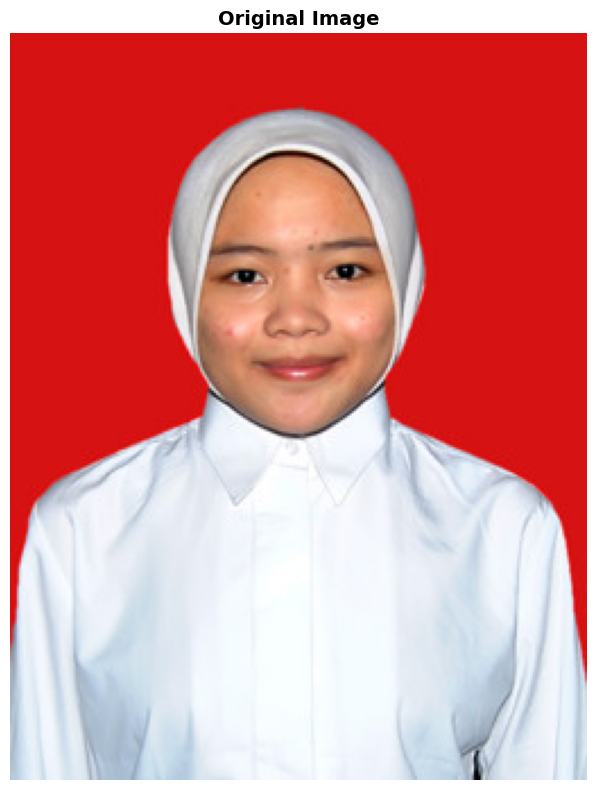


📷 Gambar Grayscale:


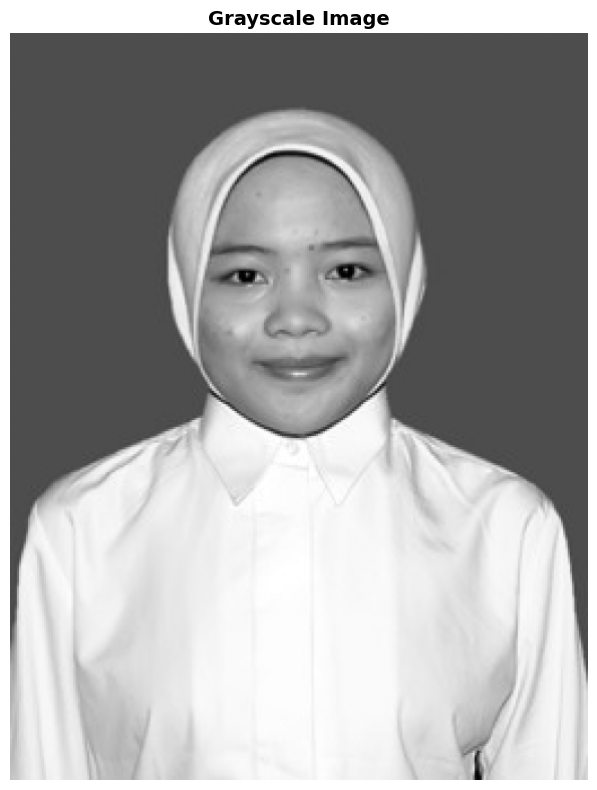


KONVERSI DENGAN BERBAGAI METHOD

🎨 Method 1: Entropy-based (LRWE)...
✓ Wavelet Entropy initialized
  - Wavelet: db4
  - Level: 2
  - Window size: 5x5
✓ Low Redundancy Wavelet Entropy initialized
  - Sampling rate: 50%

ENTROPY-BASED SKETCH CONVERSION

LOW REDUNDANCY WAVELET ENTROPY EDGE DETECTION
✓ Level 1 - Redundancy reduction: 50.0%
✓ Level 2 - Redundancy reduction: 50.0%
✓ Edge detection selesai
✓ Total computational saving: ~50%
✓ Adaptive thresholding applied
✓ Conversion complete

🎨 Method 2: DWT Standard...
✓ Wavelet Transform initialized
  - Wavelet: db4
  - Level: 3

KONVERSI FOTO KE SKETSA

DETEKSI TEPI DENGAN DWT

DEKOMPOSISI WAVELET
✓ Dekomposisi selesai dengan 3 level
✓ Approximation shape: (88, 70)
✓ Detail coefficients: 3 levels
  Level 1 - LH: (88, 70), HL: (88, 70), HH: (88, 70)
  Level 2 - LH: (170, 133), HL: (170, 133), HH: (170, 133)
  Level 3 - LH: (334, 259), HL: (334, 259), HH: (334, 259)
✓ Deteksi tepi selesai dengan metode 'magnitude'
✓ Edge map shape: (662, 

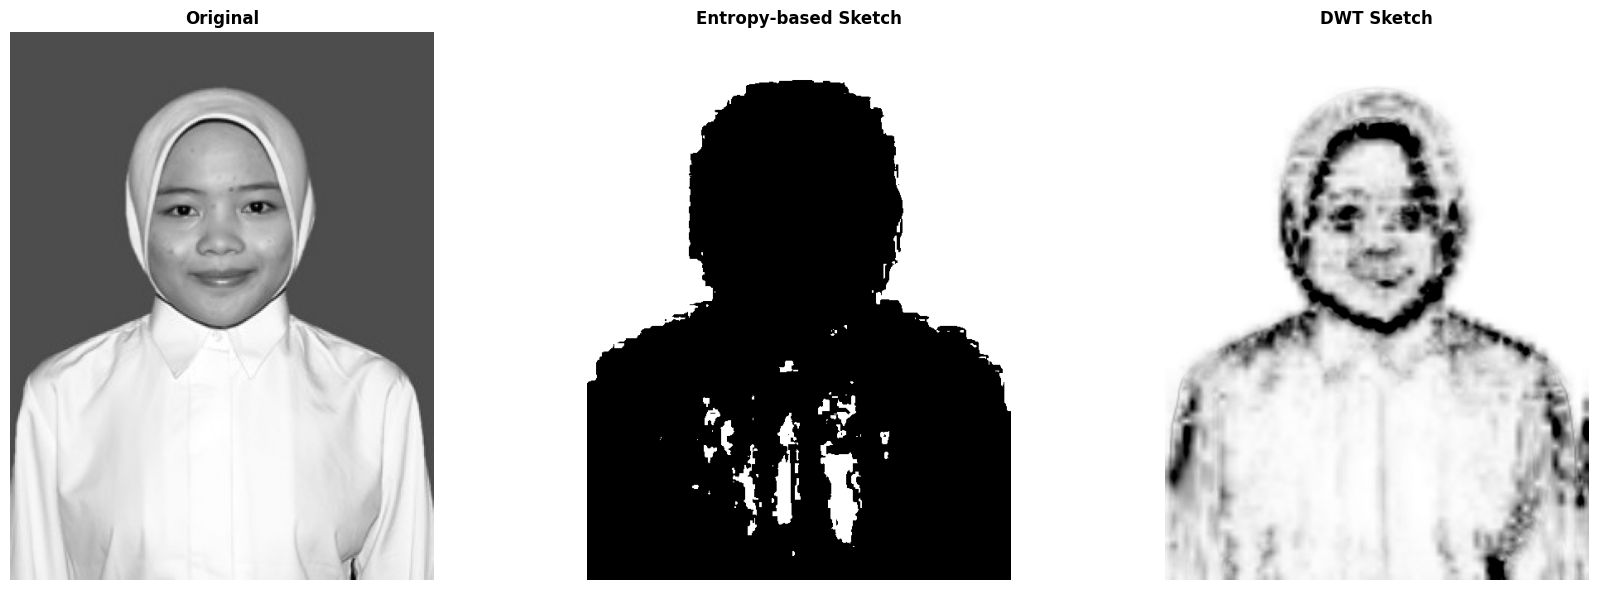

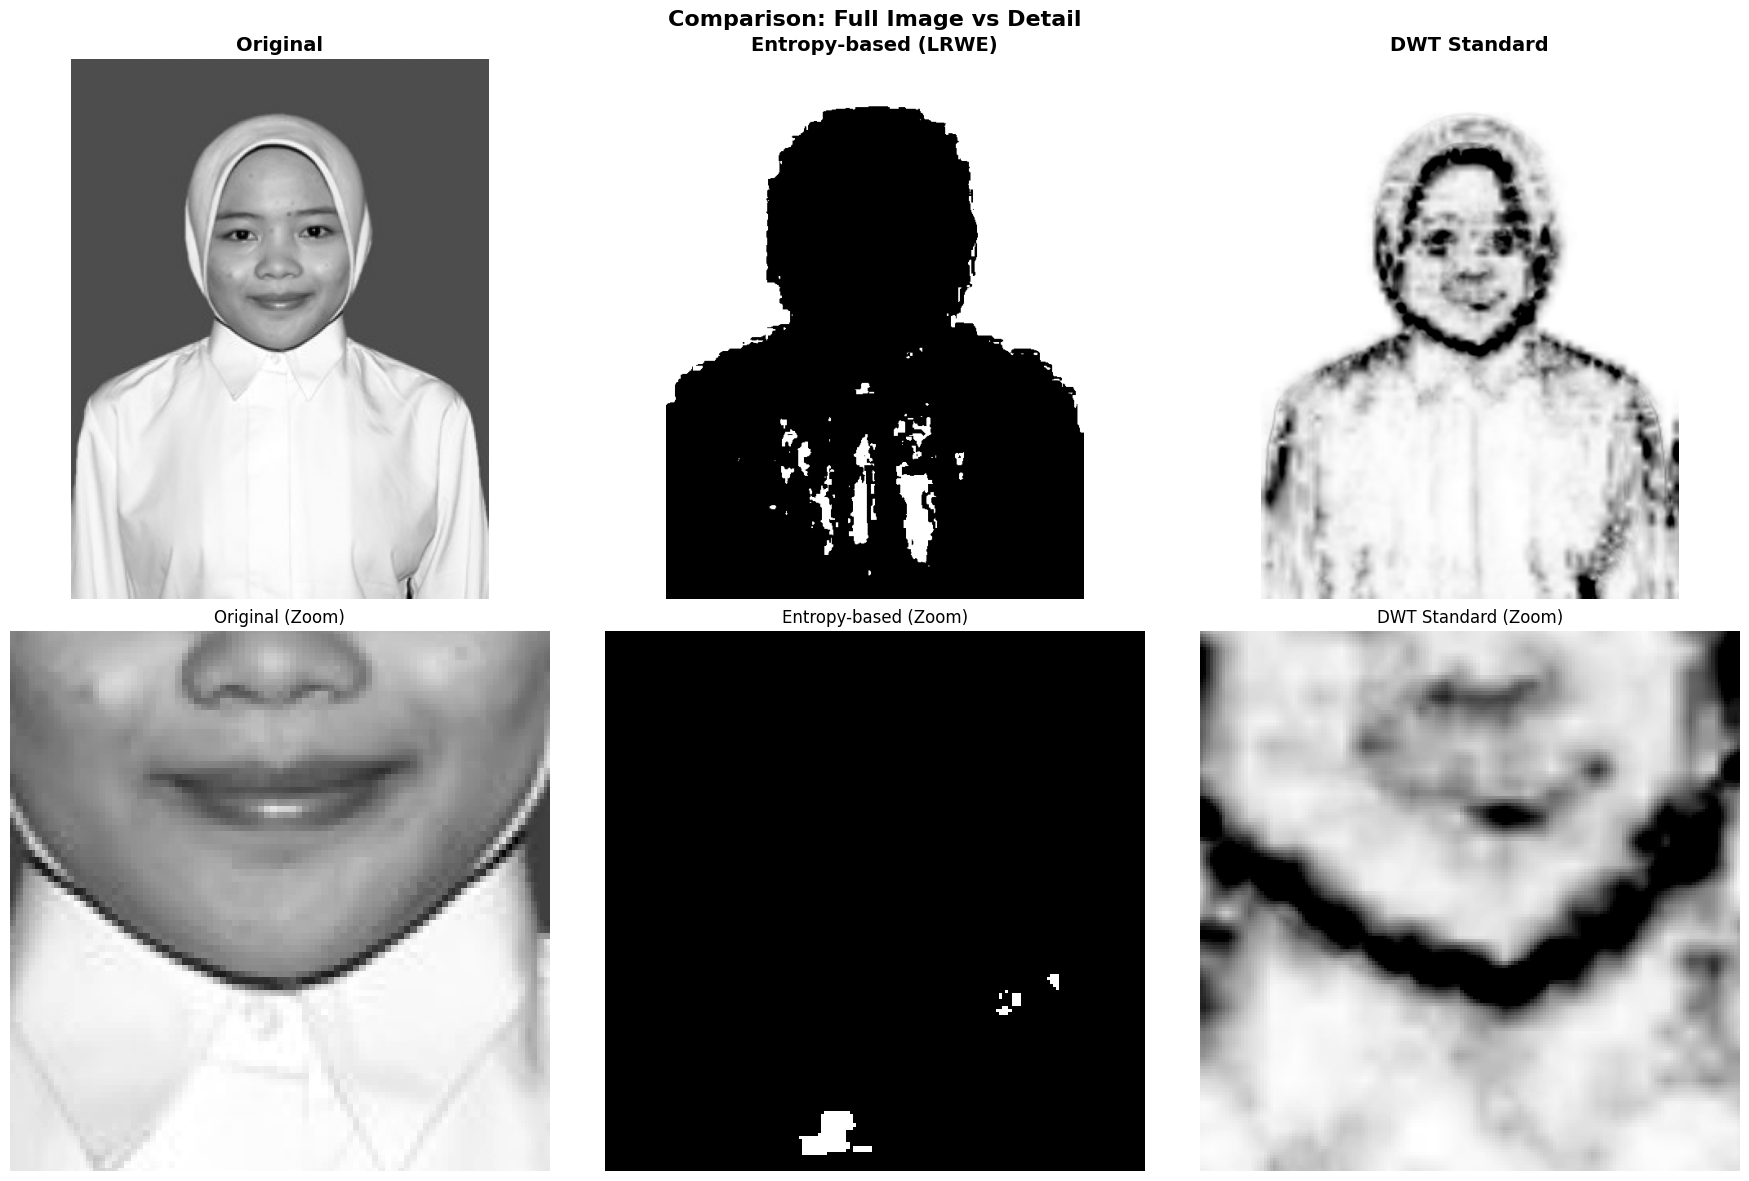


ANALISIS KUALITAS

📊 Statistik Entropy-based:
  - Min value: 0.0000
  - Max value: 1.0000
  - Mean value: 0.3736
  - Std deviation: 0.4838

📊 Statistik DWT Standard:
  - Min value: 0.0000
  - Max value: 1.0000
  - Mean value: 0.8628
  - Std deviation: 0.2255


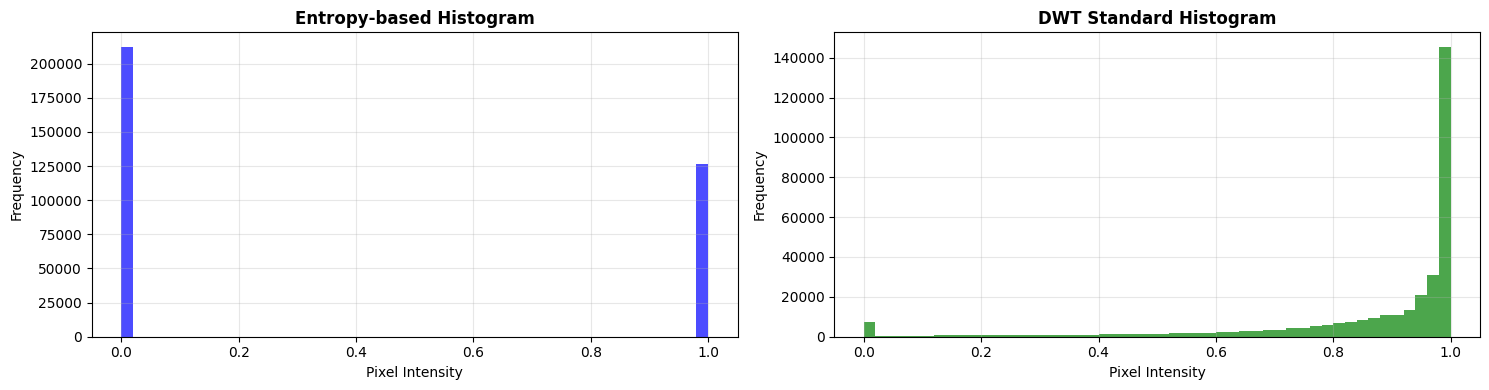


SAVE HASIL
✓ Hasil disimpan:
  - sketch_entropy.png
  - sketch_dwt.png

KESIMPULAN

✅ ENTROPY-BASED (LRWE):
  ✓ Komputasi lebih cepat (50% redundancy reduction)
  ✓ Lebih robust terhadap noise
  ✓ Cocok untuk real-time processing
  ✓ Hasil lebih clean dan smooth

✅ DWT STANDARD:
  ✓ Detail lebih kaya
  ✓ Edge detection lebih tajam
  ✓ Cocok untuk artistic sketch
  ✓ Lebih banyak texture information

💡 REKOMENDASI:
  - Gunakan ENTROPY-BASED untuk: foto portrait, real-time, mobile apps
  - Gunakan DWT STANDARD untuk: landscape, architecture, artistic purposes


In [13]:
# =========================================================================
# DEMO LENGKAP: KONVERSI FOTO KE SKETSA DENGAN WAVELET
# =========================================================================

import numpy as np
import cv2
import matplotlib.pyplot as plt

# =========================================================================
# LANGKAH 1: LOAD DAN PREPROCESSING GAMBAR
# =========================================================================

print("="*70)
print("DEMO KONVERSI FOTO KE SKETSA")
print("="*70)

# Buat instance ImageProcessor
processor = ImageProcessor()

# Pilih salah satu:
# OPSI A: Upload gambar dari komputer
print("\n📤 Upload gambar Anda:")
processor.upload_image()

# OPSI B: Gunakan sample image (uncomment jika ingin pakai sample)
# print("\n📥 Load sample image:")
# processor.load_sample_image()

# Preprocessing
print("\n🔧 Preprocessing gambar...")
gray_image = processor.preprocess(resize_width=512, normalize=True)

# Tampilkan gambar original
print("\n📷 Gambar Original:")
Visualizer.show_image(processor.original_image, "Original Image", figsize=(10, 8))

print("\n📷 Gambar Grayscale:")
Visualizer.show_image(gray_image, "Grayscale Image", figsize=(10, 8))

# =========================================================================
# LANGKAH 2: KONVERSI DENGAN BERBAGAI METHOD
# =========================================================================

print("\n" + "="*70)
print("KONVERSI DENGAN BERBAGAI METHOD")
print("="*70)

# Method 1: Entropy-based (Lebih cepat & robust terhadap noise)
print("\n🎨 Method 1: Entropy-based (LRWE)...")
converter_entropy = EntropySketchConverter(
    wavelet='db4',
    level=2,
    sampling_rate=0.5  # 50% redundancy reduction
)
sketch_entropy = converter_entropy.convert(
    gray_image,
    use_threshold=True,
    invert=True,
    enhance=1.5
)

# Method 2: DWT biasa (Lebih detail)
print("\n🎨 Method 2: DWT Standard...")
converter_dwt = SketchConverter(wavelet='db4', level=3)
sketch_dwt = converter_dwt.convert_to_sketch(
    gray_image,
    invert=True,
    enhance=2.0
)

# =========================================================================
# LANGKAH 3: VISUALISASI HASIL
# =========================================================================

print("\n" + "="*70)
print("VISUALISASI HASIL")
print("="*70)

# Perbandingan semua hasil
Visualizer.show_comparison(
    [gray_image, sketch_entropy, sketch_dwt],
    ["Original", "Entropy-based Sketch", "DWT Sketch"],
    figsize=(18, 6)
)

# Detail comparison dengan zoom
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Row 1: Full images
axes[0, 0].imshow(gray_image, cmap='gray')
axes[0, 0].set_title('Original', fontsize=14, fontweight='bold')
axes[0, 0].axis('off')

axes[0, 1].imshow(sketch_entropy, cmap='gray')
axes[0, 1].set_title('Entropy-based (LRWE)', fontsize=14, fontweight='bold')
axes[0, 1].axis('off')

axes[0, 2].imshow(sketch_dwt, cmap='gray')
axes[0, 2].set_title('DWT Standard', fontsize=14, fontweight='bold')
axes[0, 2].axis('off')

# Row 2: Zoomed center region
h, w = gray_image.shape
crop_size = min(h, w) // 3
center_h, center_w = h // 2, w // 2
y1, y2 = center_h - crop_size//2, center_h + crop_size//2
x1, x2 = center_w - crop_size//2, center_w + crop_size//2

axes[1, 0].imshow(gray_image[y1:y2, x1:x2], cmap='gray')
axes[1, 0].set_title('Original (Zoom)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(sketch_entropy[y1:y2, x1:x2], cmap='gray')
axes[1, 1].set_title('Entropy-based (Zoom)', fontsize=12)
axes[1, 1].axis('off')

axes[1, 2].imshow(sketch_dwt[y1:y2, x1:x2], cmap='gray')
axes[1, 2].set_title('DWT Standard (Zoom)', fontsize=12)
axes[1, 2].axis('off')

plt.suptitle('Comparison: Full Image vs Detail', fontsize=16, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

# =========================================================================
# LANGKAH 4: ANALISIS KUALITAS
# =========================================================================

print("\n" + "="*70)
print("ANALISIS KUALITAS")
print("="*70)

# Hitung statistik
print("\n📊 Statistik Entropy-based:")
print(f"  - Min value: {sketch_entropy.min():.4f}")
print(f"  - Max value: {sketch_entropy.max():.4f}")
print(f"  - Mean value: {sketch_entropy.mean():.4f}")
print(f"  - Std deviation: {sketch_entropy.std():.4f}")

print("\n📊 Statistik DWT Standard:")
print(f"  - Min value: {sketch_dwt.min():.4f}")
print(f"  - Max value: {sketch_dwt.max():.4f}")
print(f"  - Mean value: {sketch_dwt.mean():.4f}")
print(f"  - Std deviation: {sketch_dwt.std():.4f}")

# Histogram comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].hist(sketch_entropy.flatten(), bins=50, color='blue', alpha=0.7)
axes[0].set_title('Entropy-based Histogram', fontweight='bold')
axes[0].set_xlabel('Pixel Intensity')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

axes[1].hist(sketch_dwt.flatten(), bins=50, color='green', alpha=0.7)
axes[1].set_title('DWT Standard Histogram', fontweight='bold')
axes[1].set_xlabel('Pixel Intensity')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================================
# LANGKAH 5: SAVE HASIL (OPSIONAL)
# =========================================================================

print("\n" + "="*70)
print("SAVE HASIL")
print("="*70)

# Convert to uint8 untuk save
sketch_entropy_uint8 = (sketch_entropy * 255).astype(np.uint8)
sketch_dwt_uint8 = (sketch_dwt * 255).astype(np.uint8)

# Save dengan cv2
cv2.imwrite('sketch_entropy.png', sketch_entropy_uint8)
cv2.imwrite('sketch_dwt.png', sketch_dwt_uint8)

print("✓ Hasil disimpan:")
print("  - sketch_entropy.png")
print("  - sketch_dwt.png")

# =========================================================================
# KESIMPULAN
# =========================================================================

print("\n" + "="*70)
print("KESIMPULAN")
print("="*70)
print("\n✅ ENTROPY-BASED (LRWE):")
print("  ✓ Komputasi lebih cepat (50% redundancy reduction)")
print("  ✓ Lebih robust terhadap noise")
print("  ✓ Cocok untuk real-time processing")
print("  ✓ Hasil lebih clean dan smooth")

print("\n✅ DWT STANDARD:")
print("  ✓ Detail lebih kaya")
print("  ✓ Edge detection lebih tajam")
print("  ✓ Cocok untuk artistic sketch")
print("  ✓ Lebih banyak texture information")

print("\n💡 REKOMENDASI:")
print("  - Gunakan ENTROPY-BASED untuk: foto portrait, real-time, mobile apps")
print("  - Gunakan DWT STANDARD untuk: landscape, architecture, artistic purposes")
print("="*70)